# FWI vs FRP — Daytime and Nighttime

Thailand region (5.5°N–20.5°N, 97.5°E–105.5°E), March 2022 – February 2024.

| Data source | Parameters | Spatial res. | Temporal | Reference |
|---|---|---|---|---|
| Copernicus C3S SLSTR Level-3 (Sentinel-3A & 3B) | Daily mean FRP | 0.1° × 0.1° | 2022–2024 | Donlon et al. (2012); Coppo et al. (2010); Wooster et al. (2012); Copernicus C3S (2021) |
| ECMWF ERA5 reanalysis (EFFIS) | Daily mean FWI | 0.25° × 0.25° | 2022–2024 | Vitolo et al. (2020); Copernicus Climate Change Service (2019) |

## 1. Imports and Configuration

Load Python libraries (`numpy`, `xarray`, `scipy`, `matplotlib`) and define the study region (Thailand: 5.5–20.5°N, 97.5–105.5°E) and time window (March 2022 – February 2024).

In [3]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit

# ── Data paths ────────────────────────────────────────────────────────────────
BASE_FRP  = '/Volumes/jubjang/Jubjang'
BASE_FWI  = '/Volumes/jubjang/Jubjang/FWI2022-2024'

# Study period
TIME_RANGE = slice('2022-03-01', '2024-02-28')

# Thailand bounding box
LAT_RANGE = slice(20.5, 5.5)   # descending (S3 lat order)
LON_RANGE = slice(97.5, 105.5)


## 2. Data Loading

Load Sentinel-3A/3B SLSTR Level-3 FRP (0.1° × 0.1°, daily, separate daytime/nighttime products) and ERA5 EFFIS FWI (0.25° × 0.25°, daily) for the study period using `xarray`.

In [5]:
# Sentinel-3A & 3B SLSTR Level-3 daily FRP (0.1°)
gfas_fire_xrS3A_D = xr.open_mfdataset(
    f'{BASE_FRP}/realday2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3A-daytime-fv1.2.nc',
    combine='by_coords', engine='netcdf4')
gfas_fire_xrS3B_D = xr.open_mfdataset(
    f'{BASE_FRP}/realday2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3B-daytime-fv1.2.nc',
    combine='by_coords', engine='netcdf4')
gfas_fire_xrS3A_N = xr.open_mfdataset(
    f'{BASE_FRP}/realnight2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3A-nighttime-fv1.2.nc',
    combine='by_coords', engine='netcdf4')
gfas_fire_xrS3B_N = xr.open_mfdataset(
    f'{BASE_FRP}/realnight2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3B-nighttime-fv1.2.nc',
    combine='by_coords', engine='netcdf4')

# ERA5-based FWI
fwi_dataset1 = xr.open_mfdataset(
    f'{BASE_FWI}/23b9822648b94e71f5b65e6f2d4054a6.nc',
    combine='by_coords', engine='netcdf4')


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_34040/3105041157.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gfas_fire_xrS3A_D = xr.open_mfdataset(
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_34040/3105041157.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gfas_fire_xrS3B_D

## 3. Preprocessing

Parse and align daytime/nighttime timestamps, regrid FRP from 0.1° to the FWI 0.25° grid, extract the Thailand bounding box, and pair FWI–FRP values on matching days.

In [7]:
def _set_frp_time(ds, is_daytime):
    """Snap FRP time coordinate to daily resolution (12:00 daytime, 00:00 nighttime)."""
    ds['time'] = pd.to_datetime(ds['time'].dt.floor('D'))
    if is_daytime:
        ds['time'] = ds['time'] + pd.Timedelta(hours=12)
    return ds

gfas_fire_xrS3A_D = _set_frp_time(gfas_fire_xrS3A_D, is_daytime=True)
gfas_fire_xrS3B_D = _set_frp_time(gfas_fire_xrS3B_D, is_daytime=True)
gfas_fire_xrS3A_N = _set_frp_time(gfas_fire_xrS3A_N, is_daytime=False)
gfas_fire_xrS3B_N = _set_frp_time(gfas_fire_xrS3B_N, is_daytime=False)

def _combine_s3(da_A, da_B):
    """
    Merge S3A and S3B by taking the available value when only one is present,
    or their average when both are present.
    """
    a, b = xr.align(da_A, da_B, join='outer', fill_value=0)
    return xr.where(
        a.notnull() & b.isnull(), a,
        xr.where(a.isnull() & b.notnull(), b, (a + b) / 2)
    ).fillna(np.nan)

frp_combined_D = _combine_s3(
    gfas_fire_xrS3A_D['frp'].sel(time=TIME_RANGE, lat=LAT_RANGE, lon=LON_RANGE),
    gfas_fire_xrS3B_D['frp'].sel(time=TIME_RANGE, lat=LAT_RANGE, lon=LON_RANGE),
)
frp_combined_N = _combine_s3(
    gfas_fire_xrS3A_N['frp'].sel(time=TIME_RANGE, lat=LAT_RANGE, lon=LON_RANGE),
    gfas_fire_xrS3B_N['frp'].sel(time=TIME_RANGE, lat=LAT_RANGE, lon=LON_RANGE),
)

# Daily cumulative FRP over Thailand
sum_frp_D = frp_combined_D.sum(dim=['lat', 'lon'])
sum_frp_N = frp_combined_N.sum(dim=['lat', 'lon'])


In [8]:
def _set_fwi_time(ds, is_daytime):
    """Assign FWI valid_time to match FRP daytime (12:00) or nighttime (00:00) stamps."""
    ds = ds.assign_coords(valid_time=pd.to_datetime(ds['valid_time'].dt.floor('D')))
    if is_daytime:
        ds = ds.assign_coords(valid_time=ds['valid_time'] + pd.Timedelta(hours=12))
    return ds

fwi_D = _set_fwi_time(fwi_dataset1, is_daytime=True).sel(valid_time=TIME_RANGE)
fwi_N = _set_fwi_time(fwi_dataset1, is_daytime=False).sel(valid_time=TIME_RANGE)

# Area-mean FWI over Thailand
mean_fwi_D = fwi_D.sel(latitude=LAT_RANGE, longitude=LON_RANGE)['fwinx'].mean(dim=['latitude', 'longitude'])
mean_fwi_N = fwi_N.sel(latitude=LAT_RANGE, longitude=LON_RANGE)['fwinx'].mean(dim=['latitude', 'longitude'])


In [9]:
def _align_and_extract(fwi_da, frp_da):
    """Inner-join FWI and FRP on time, return matched numpy arrays."""
    fwi_al, frp_al = xr.align(fwi_da, frp_da, join='inner')
    fwi_vals = fwi_al.values
    frp_vals = frp_al.values
    if fwi_vals.shape != frp_vals.shape:
        n = min(len(fwi_vals), len(frp_vals))
        fwi_vals, frp_vals = fwi_vals[:n], frp_vals[:n]
    return fwi_vals, frp_vals

mean_fwi_values_D, sum_frp_values_D = _align_and_extract(mean_fwi_D, sum_frp_D)
mean_fwi_values_N, sum_frp_values_N = _align_and_extract(mean_fwi_N, sum_frp_N)


## 4. Regression Fits and Figure

Fit a linear regression (daytime) and a logistic curve (nighttime) using `scipy`; compute R², RMSE, and χ² for each regime; produce a two-panel scatter figure.

### Goodness-of-Fit Metrics

The following metrics are used to evaluate each regression model:

---

#### Coefficient of Determination (R²)

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum_{i}(y_i - \hat{y}_i)^2}{\sum_{i}(y_i - \bar{y})^2}$$

where $y_i$ are observed values, $\hat{y}_i$ are model-predicted values, and $\bar{y}$ is the mean of observed values.  
$R^2 \in [0, 1]$; a value closer to 1 indicates a better fit.

---

#### Adjusted R²

$$\text{Adj.}\ R^2 = 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1}$$

where $n$ is the number of observations and $p$ is the number of model parameters (excluding the intercept).  
Adjusted R² penalises model complexity, making it comparable across models with different numbers of parameters.

---

#### Root Mean Square Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

RMSE measures the average magnitude of prediction errors in the same units as FRP (MW).  
Lower RMSE indicates better predictive accuracy.

---

#### Chi-Square Statistic (χ²)

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{y}_i)^2}{\hat{y}_i}$$

Each squared residual is normalised by the expected (predicted) value, making χ² sensitive to relative errors rather than absolute ones.  
Non-positive predicted values are replaced by the minimum positive predicted value to avoid division by zero.  
Lower χ² indicates a better fit relative to the scale of the predictions.

---

### Regression Model Equations

| Model | Equation | Parameters |
|---|---|---|
| Linear | $y = ax + b$ | slope $a$, intercept $b$ |
| Exponential | $y = a\,e^{bx}$ | $a$, $b$ |
| Power Law | $y = a\,x^{b}$ | $a$, $b$ |
| Logistic | $y = \dfrac{L}{1 + e^{-k(x - x_0)}}$ | carrying capacity $L$, midpoint $x_0$, growth rate $k$ |

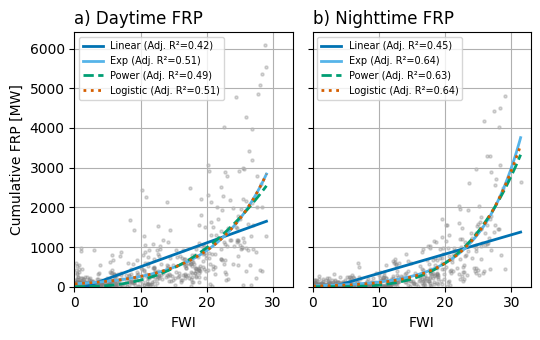

In [12]:
# Okabe-Ito colour-blind-safe palette
colors = {
    'blue':     '#0072B2',
    'sky_blue': '#56B4E9',
    'green':    '#009E73',
    'red':      '#D55E00',
}

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def _r2_ss(y, y_pred):
    """R² via explicit sum-of-squares (consistent with P1_DayNight)."""
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def _fit_panel(fwi_vals, frp_vals):
    """Filter valid points and fit four regression models."""
    mask = (frp_vals > 0) & ~np.isnan(fwi_vals) & ~np.isnan(frp_vals)
    x, y = fwi_vals[mask], frp_vals[mask]
    n = len(x)

    # Linear
    slope, intercept, r, _, _ = linregress(x, y)
    adj_r2_lin = adjusted_r2(r**2, n, p=1)

    # Exponential
    def exponential(x, a, b): return a * np.exp(b * x)
    p_exp, _ = curve_fit(exponential, x, y, p0=[y.min(), 0.01], maxfev=5000)
    adj_r2_exp = adjusted_r2(_r2_ss(y, exponential(x, *p_exp)), n, p=2)

    # True power law: y = a * x^b
    def power_law(x, a, b): return a * (x ** b)
    p_pow, _ = curve_fit(power_law, x, y, p0=[1, 2], maxfev=5000)
    adj_r2_pow = adjusted_r2(_r2_ss(y, power_law(x, *p_pow)), n, p=2)

    # Logistic
    def logistic(x, L, x0, k): return L / (1 + np.exp(-k * (x - x0)))
    p_log, _ = curve_fit(logistic, x, y,
                         p0=[y.max(), np.median(x), 1], maxfev=5000)
    adj_r2_log = adjusted_r2(_r2_ss(y, logistic(x, *p_log)), n, p=3)

    return (x, y,
            slope, intercept, adj_r2_lin,
            exponential, p_exp, adj_r2_exp,
            power_law,   p_pow, adj_r2_pow,
            logistic,    p_log, adj_r2_log)


def _draw_panel(ax, results, title):
    (x, y,
     slope, intercept, adj_r2_lin,
     exponential, p_exp, adj_r2_exp,
     power_law,   p_pow, adj_r2_pow,
     logistic,    p_log, adj_r2_log) = results

    ax.scatter(x, y, s=5, alpha=0.3, color='gray')
    xl = np.linspace(x.min(), x.max(), 1000)

    ax.plot(xl, slope * xl + intercept,
            color=colors['blue'],     lw=2,
            label=f'Linear (Adj. R²={adj_r2_lin:.2f})')
    ax.plot(xl, exponential(xl, *p_exp),
            color=colors['sky_blue'], lw=2,
            label=f'Exp (Adj. R²={adj_r2_exp:.2f})')
    ax.plot(xl, power_law(xl, *p_pow),
            color=colors['green'],    lw=2, ls='--',
            label=f'Power (Adj. R²={adj_r2_pow:.2f})')
    ax.plot(xl, logistic(xl, *p_log),
            color=colors['red'],      lw=2, ls=':',
            label=f'Logistic (Adj. R²={adj_r2_log:.2f})')

    ax.set_title(title, loc='left', fontsize=12)
    ax.set_xlabel('FWI', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True)


res_D = _fit_panel(mean_fwi_values_D, sum_frp_values_D)
res_N = _fit_panel(mean_fwi_values_N, sum_frp_values_N)

os.makedirs('Pict', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(5.51, 3.5), sharex=True, sharey=True)
_draw_panel(axes[0], res_D, 'a) Daytime FRP')
_draw_panel(axes[1], res_N, 'b) Nighttime FRP')
axes[0].set_ylabel('Cumulative FRP [MW]', fontsize=10)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('Pict/FWI_FRP_Daytime_Nighttime_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
def _print_metrics(res, label):
    (x, y,
     slope, intercept, adj_r2_lin,
     exponential, p_exp, adj_r2_exp,
     power_law,   p_pow, adj_r2_pow,
     logistic,    p_log, adj_r2_log) = res

    rmse = lambda pred: np.sqrt(np.mean((y - pred) ** 2))

    def chi2(pred):
        # replace non-positive expected with min positive
        expected = np.where(pred > 0, pred, np.min(pred[pred > 0]))
        return np.sum((y - expected) ** 2 / expected)

    print(f"{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  n = {len(x)}\n")

    print(f"  [Linear]")
    print(f"    Equation : y = {slope:.4f}x + {intercept:.4f}")
    print(f"    Adj. R²  : {adj_r2_lin:.4f}")
    print(f"    RMSE     : {rmse(slope*x + intercept):.4f}")
    print(f"    χ²       : {chi2(slope*x + intercept):.4f}\n")

    print(f"  [Exponential]")
    print(f"    Equation : y = {p_exp[0]:.4f} × exp({p_exp[1]:.4f}x)")
    print(f"    Adj. R²  : {adj_r2_exp:.4f}")
    print(f"    RMSE     : {rmse(exponential(x, *p_exp)):.4f}")
    print(f"    χ²       : {chi2(exponential(x, *p_exp)):.4f}\n")

    print(f"  [Power Law]")
    print(f"    Equation : y = {p_pow[0]:.4f} × x^({p_pow[1]:.4f})")
    print(f"    Adj. R²  : {adj_r2_pow:.4f}")
    print(f"    RMSE     : {rmse(power_law(x, *p_pow)):.4f}")
    print(f"    χ²       : {chi2(power_law(x, *p_pow)):.4f}\n")

    print(f"  [Logistic]")
    print(f"    Equation : y = {p_log[0]:.4f} / (1 + exp(-{p_log[2]:.4f}(x - {p_log[1]:.4f})))")
    print(f"    Adj. R²  : {adj_r2_log:.4f}")
    print(f"    RMSE     : {rmse(logistic(x, *p_log)):.4f}")
    print(f"    χ²       : {chi2(logistic(x, *p_log)):.4f}")
    print()

_print_metrics(res_D, "Daytime FRP")
_print_metrics(res_N, "Nighttime FRP")

  Daytime FRP
  n = 635

  [Linear]
    Equation : y = 60.2391x + -99.0577
    Adj. R²  : 0.4195
    RMSE     : 609.1819
    χ²       : 3128667.4721

  [Exponential]
    Equation : y = 73.6771 × exp(0.1259x)
    Adj. R²  : 0.5121
    RMSE     : 558.0687
    χ²       : 265742.0163

  [Power Law]
    Equation : y = 0.4678 × x^(2.5538)
    Adj. R²  : 0.4893
    RMSE     : 570.9427
    χ²       : 96295641.9389

  [Logistic]
    Equation : y = 45753155.8790 / (1 + exp(-0.1259(x - 105.9886)))
    Adj. R²  : 0.5113
    RMSE     : 558.0692
    χ²       : 265747.8502

  Nighttime FRP
  n = 635

  [Linear]
    Equation : y = 48.5380x + -149.1843
    Adj. R²  : 0.4524
    RMSE     : 460.3177
    χ²       : 880549.5592

  [Exponential]
    Equation : y = 23.5048 × exp(0.1615x)
    Adj. R²  : 0.6420
    RMSE     : 371.8886
    χ²       : 123784.4800

  [Power Law]
    Equation : y = 0.0063 × x^(3.8207)
    Adj. R²  : 0.6349
    RMSE     : 375.5488
    χ²       : 62711772885.0847

  [Logistic]
    E